In [21]:
from keras import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.datasets import fashion_mnist
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [22]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


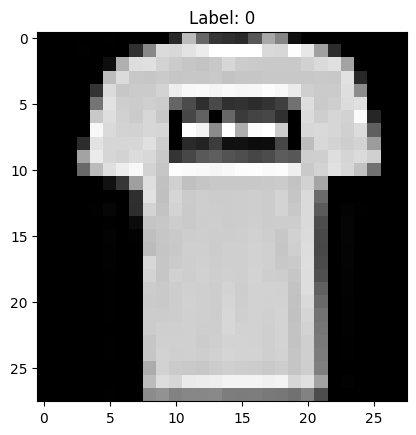

In [23]:
img=x_train[1,:,:]
label=y_train[1]
plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [24]:
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255
x_test=x_test.reshape(-1,28,28,1).astype('float32')/255
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

In [25]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [27]:
history=model.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7083 - loss: 0.8430 - val_accuracy: 0.8408 - val_loss: 0.4389
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8609 - loss: 0.3877 - val_accuracy: 0.8677 - val_loss: 0.3646
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8852 - loss: 0.3225 - val_accuracy: 0.8838 - val_loss: 0.3184
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8985 - loss: 0.2810 - val_accuracy: 0.8899 - val_loss: 0.3015
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9036 - loss: 0.2611 - val_accuracy: 0.8965 - val_loss: 0.2862


In [28]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8891 - loss: 0.3064
Test loss: 0.2947259545326233
Test accuracy: 0.892300009727478


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


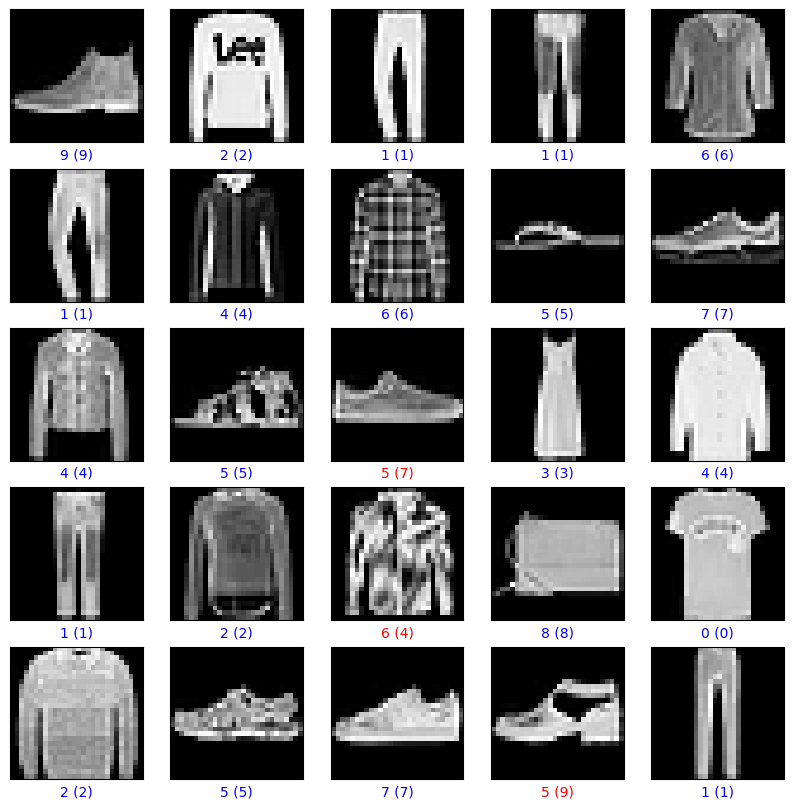

In [29]:
predictions=model.predict(x_test)
predicted_labels=np.argmax(predictions,axis=1)
true_labels=np.argmax(y_test,axis=1)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    color='blue' if predicted_labels[i] == true_labels[i] else 'red'
    plt.xlabel(f"{predicted_labels[i]} ({true_labels[i]})", color=color)
plt.show()

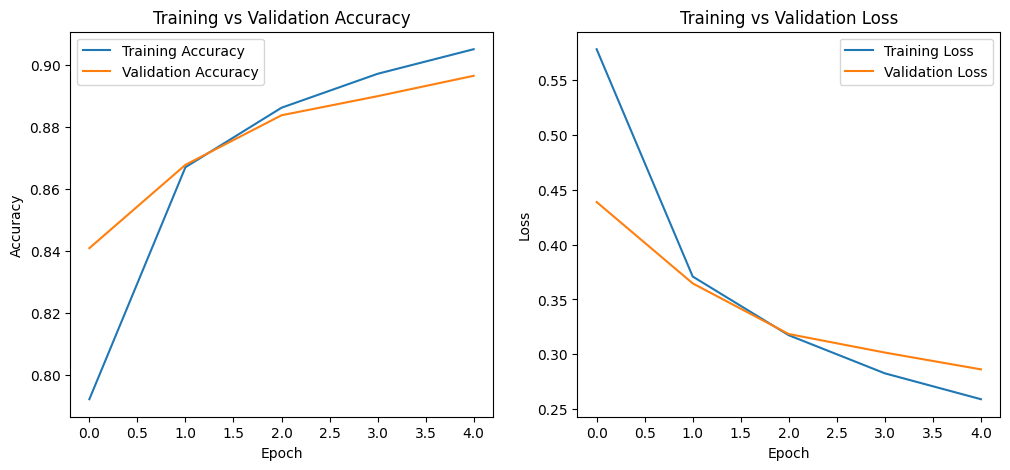

In [30]:
#Plot training accuracy vs validation accuracy
#Plot training loss vs validation loss
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

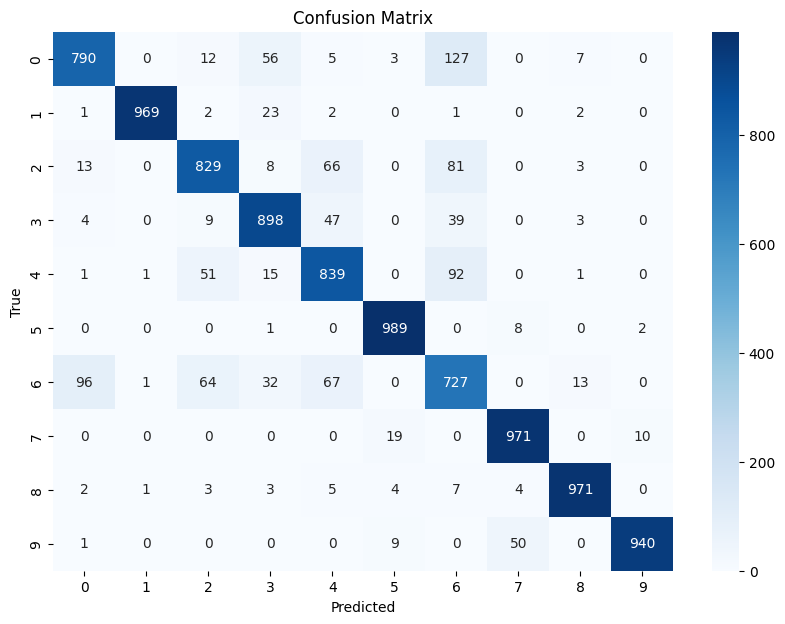

In [31]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm=confusion_matrix(true_labels,predicted_labels)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [32]:
from keras.layers import Dropout
def build_model(dropout_rate=0.5, filters1=32, filters2=64, filters3=128):
    model=Sequential()
    model.add(Conv2D(filters1,(3,3),activation='relu',input_shape=(28,28,1)))
    model.add(Conv2D(filters1,(3,3),activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(filters2,(3,3),activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(filters3,(3,3),activation='relu'))
    model.add(Flatten())
    model.add(Dense(128,activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(10,activation='softmax'))
    return model
model2=build_model(dropout_rate=0.5, filters1=64, filters2=128, filters3=256)
model2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,922 (2.68 MB)

 Trainable params: 702,922 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [34]:
history2=model2.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6466 - loss: 0.9751 - val_accuracy: 0.8579 - val_loss: 0.3878
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8544 - loss: 0.4130 - val_accuracy: 0.8863 - val_loss: 0.3161
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8799 - loss: 0.3362 - val_accuracy: 0.8978 - val_loss: 0.2753
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8980 - loss: 0.2871 - val_accuracy: 0.9057 - val_loss: 0.2653
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9074 - loss: 0.2557 - val_accuracy: 0.9137 - val_loss: 0.2374


In [35]:
test_loss2,test_acc2=model2.evaluate(x_test,y_test)
print(f"Model 1 Test accuracy: {test_acc}")
print(f"Model 2 Test accuracy: {test_acc2}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9104 - loss: 0.2635
Model 1 Test accuracy: 0.892300009727478
Model 2 Test accuracy: 0.9107000231742859


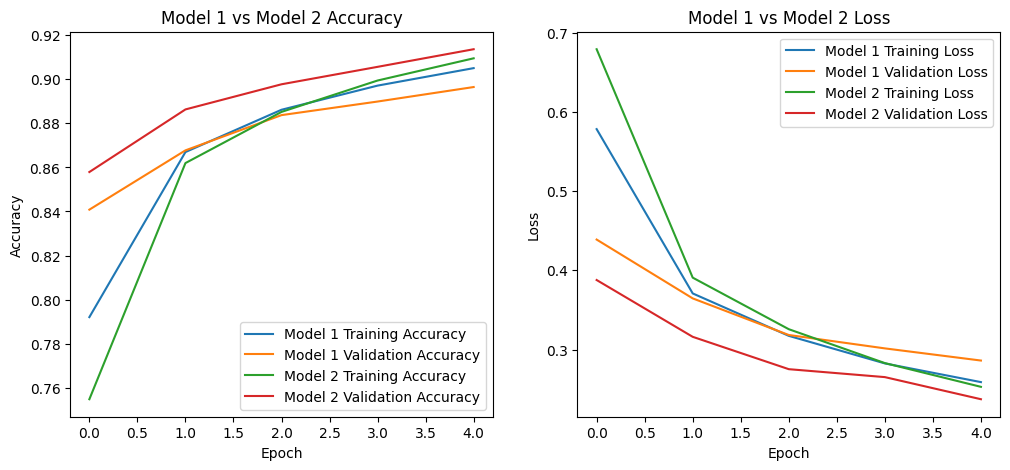

In [36]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Model 1 Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Model 1 Validation Accuracy')
plt.plot(history2.history['accuracy'], label='Model 2 Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Model 2 Validation Accuracy')
plt.title('Model 1 vs Model 2 Accuracy')
plt.xlabel('Epoch') 
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Model 1 Training Loss')
plt.plot(history.history['val_loss'], label='Model 1 Validation Loss')
plt.plot(history2.history['loss'], label='Model 2 Training Loss')
plt.plot(history2.history['val_loss'], label='Model 2 Validation Loss')
plt.title('Model 1 vs Model 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

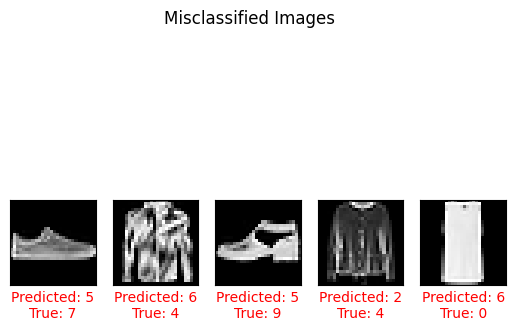

In [37]:
misclassified_indices=np.where(predicted_labels != true_labels)[0]
for i, idx in enumerate(misclassified_indices[:5]):
    plt.subplot(1,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.xlabel(f"Predicted: {predicted_labels[idx]}\nTrue: {true_labels[idx]}", color='red')
plt.suptitle("Misclassified Images")
plt.show()

In [38]:
from keras.models import Model
layer_outputs=[layer.output for layer in model.layers if isinstance(layer,Conv2D)]
activation_model=Model(inputs=model.inputs, outputs=layer_outputs)
test_image=x_test[0].reshape(1,28,28,1)
activations=activation_model.predict(test_image)
layer_names=[layer.name for layer in model.layers if isinstance(layer,Conv2D)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


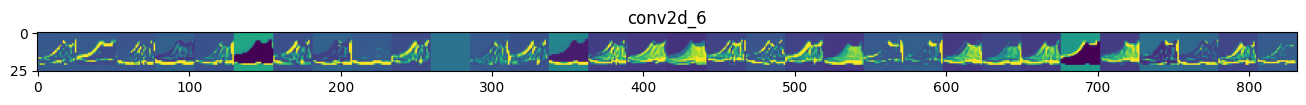

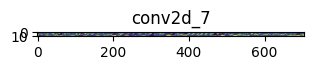

In [39]:
for layer_name, activation in zip(layer_names, activations):
    num_filters=activation.shape[-1]
    size=activation.shape[1]
    display_grid=np.zeros((size,size*num_filters))
    for i in range(num_filters):
        filter_activation=activation[0,:,:,i]
        filter_activation-=filter_activation.mean()
        filter_activation/=filter_activation.std()+1e-5
        filter_activation*=64
        filter_activation+=128
        filter_activation=np.clip(filter_activation,0,255).astype('uint8')
        display_grid[:,i*size:(i+1)*size]=filter_activation
    scale=20./num_filters
    plt.figure(figsize=(scale*size,scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid,cmap='viridis')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


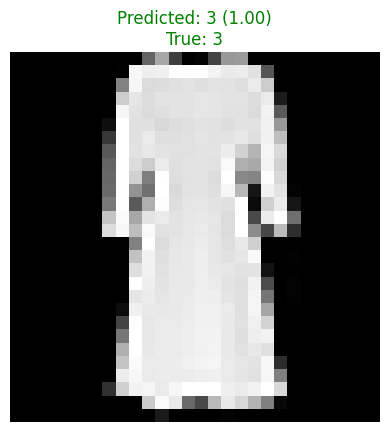

In [40]:
random_idx=np.random.randint(0,len(x_test))
random_image=x_test[random_idx].reshape(1,28,28,1)
prediction=model.predict(random_image)
predicted_label=np.argmax(prediction)
predicted_prob=np.max(prediction)
true_label=np.argmax(y_test[random_idx])
plt.imshow(random_image.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_label} ({predicted_prob:.2f})\nTrue: {true_label}", color='green' if predicted_label==true_label else 'red')
plt.axis('off')
plt.show()